# Exploratory Data Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data/penguins.csv")
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


## Structural Overview

In [3]:
df.shape

(344, 7)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB


In [5]:
df.sample(5)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,FEMALE
273,Gentoo,Biscoe,50.1,15.0,225.0,5000.0,MALE
281,Gentoo,Biscoe,46.2,14.9,221.0,5300.0,MALE
294,Gentoo,Biscoe,46.4,15.0,216.0,4700.0,FEMALE
279,Gentoo,Biscoe,50.4,15.3,224.0,5550.0,MALE


## Missing Data

In [6]:
df.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

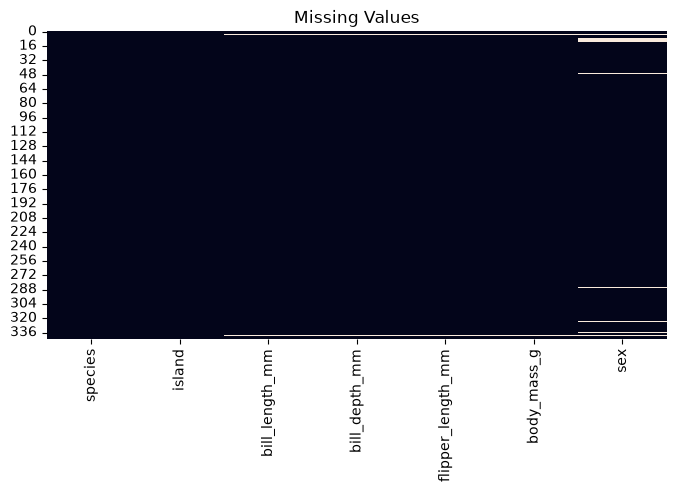

In [7]:
plt.figure(figsize=(8, 4))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values")
plt.show()

## Categorical Columns

In [8]:
df["species"].value_counts()

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

In [9]:
df["island"].value_counts()

island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64

In [10]:
df["sex"].value_counts()

sex
MALE      168
FEMALE    165
Name: count, dtype: int64

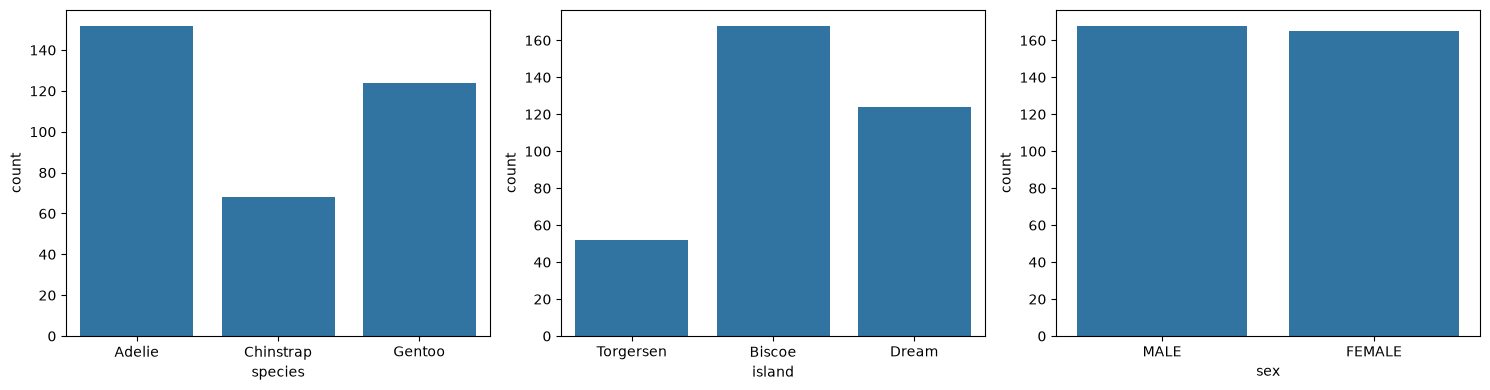

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(data=df, x="species", ax=axes[0])
sns.countplot(data=df, x="island", ax=axes[1])
sns.countplot(data=df, x="sex", ax=axes[2])
plt.tight_layout()
plt.show()

## Numeric Columns

In [12]:
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


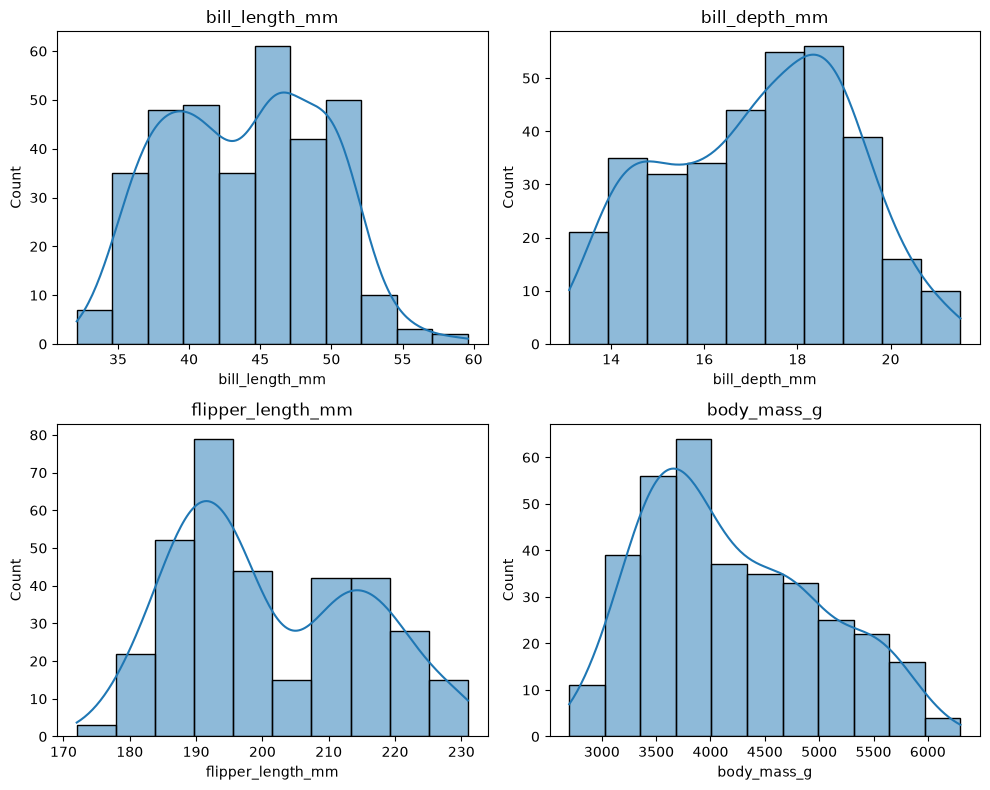

In [13]:
numeric_cols = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for col, ax in zip(numeric_cols, axes.flatten()):
    sns.histplot(df[col].dropna(), kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## Relationships

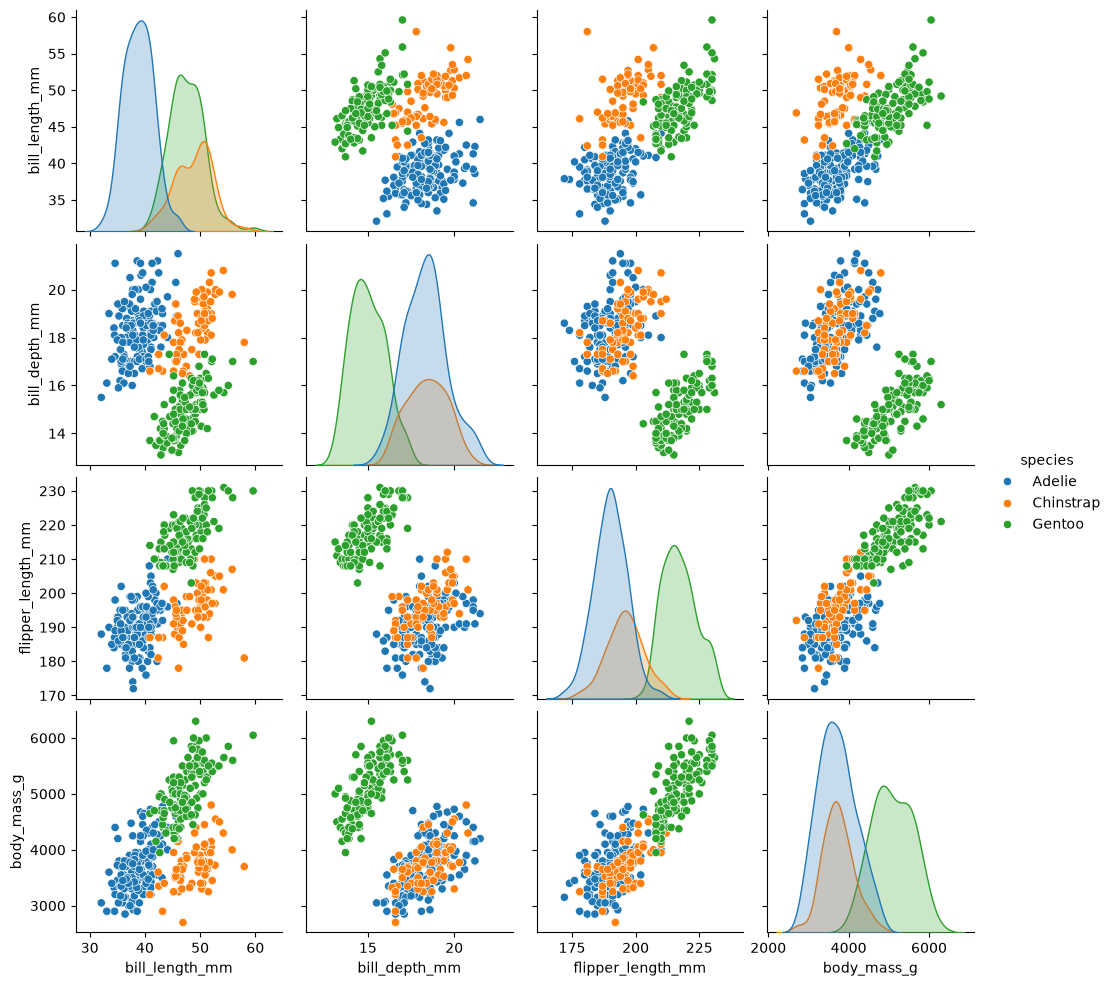

In [14]:
sns.pairplot(df.dropna(), hue="species", vars=numeric_cols)
plt.show()

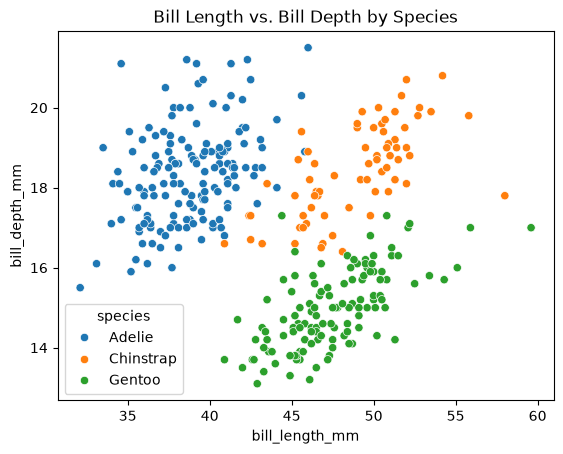

In [15]:
sns.scatterplot(data=df, x="bill_length_mm", y="bill_depth_mm", hue="species")
plt.title("Bill Length vs. Bill Depth by Species")
plt.show()

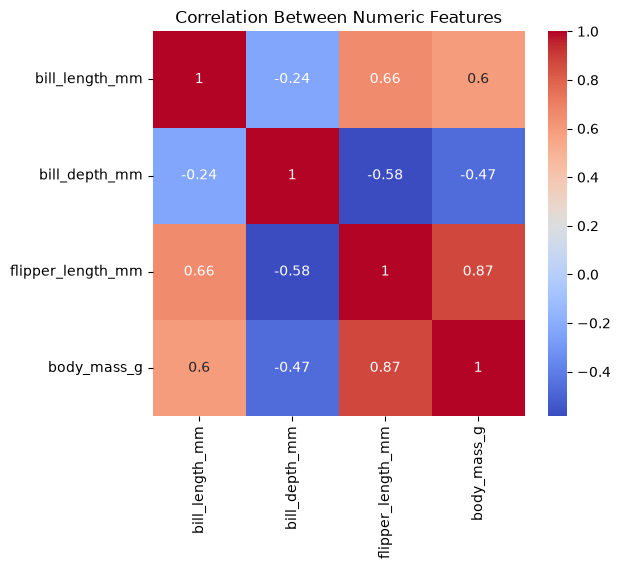

In [16]:
plt.figure(figsize=(6, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Between Numeric Features")
plt.show()

## Class Balance

In [17]:
df["species"].value_counts(normalize=True)

species
Adelie       0.441860
Gentoo       0.360465
Chinstrap    0.197674
Name: proportion, dtype: float64